# Lunar Orbit Mock — Multi-Frequency 21cm Analysis

Repeat the monopole inversion across a frequency grid (55–115 MHz),
filter the recovered spectrum using beam-weighted GSM spectral eigenmodes,
and compare against a library of 646 detailed 21cm signal models.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import healpy
from scipy.spatial.transform import Rotation
from astropy.time import Time
from astropy.coordinates import get_body
import astropy.units as u

from eigsep_sim.lunar_orbit import LunarOrbit, OrbiterMission
from eigsep_sim.const import R_MOON
from eigsep_sim.beam import thin_dipole_pattern
from eigsep_sim.sky import SkyModel
from eigsep_sim.sim import compute_masks_and_beams, compute_beams, simulate_observations
from eigsep_sim.linear_solver import (
    build_design_matrix, normal_solve,
)
from eigsep_sim.models import T21cmModel
from eigsep_sim.spectral import gsm_eigenmodes, eigenmode_filter

## Configuration

In [2]:
_YAML = os.path.join(os.path.dirname(os.path.abspath('__file__')), "bloom_config.yaml")
cfg = OrbiterMission(_YAML)

print(cfg)
print(f"Orbits: {cfg.observation.n_orbits},  Pixels: {cfg.observation.npix},  "
      f"Observations: {cfg.observation.n_rows} ({cfg.observation.n_orbits} orbits × {cfg.observation.n_obs} times × 2 dipoles)")
for o, v in enumerate(cfg.observation.rot_orbit_vecs):
    print(f"  orbit {o} normal (galactic): {v.round(4)}")
print(f"Arm lengths: {cfg.antenna.arm_lengths} m,  masses: {cfg.antenna.arm_masses} kg,  "
      f"opening angle: {cfg.antenna.opening_angle_deg}°")
print(f"Attitude model: {'fixed spin around cfg.antenna.l_hat' if cfg.observation.fixed_spin else 'ergodic tumbling (random SO(3))'}")

OrbiterMission(freq=100 MHz, nside=8, alt=150 km, n_orbits=2, n_obs=14400, Δν=390.62 kHz, τ=10.0 s, L=[6.0, 4.0] m, Trx=100.0 K)
Orbits: 2,  Pixels: 768,  Observations: 57600 (2 orbits × 14400 times × 2 dipoles)
  orbit 0 normal (galactic): [-0.4838  0.747   0.456 ]
  orbit 1 normal (galactic): [-0.0549  0.4941 -0.8677]
Arm lengths: [6.0, 4.0] m,  masses: [1.0, 2.25] kg,  opening angle: 90.0°
Attitude model: ergodic tumbling (random SO(3))


## Spacecraft orientations

Two attitude models are supported, selected by `cfg.observation.fixed_spin` in
`bloom_config.yaml`.

**Ergodic tumbling** (`cfg.observation.fixed_spin = False`, default):
The L and I of the spinner are designed so that the torque-free precession
is ergodic — the body visits all orientations with roughly equal probability
over a month.  We model the attitude at each observation epoch as an
independent draw from the uniform (Haar) measure on SO(3), which is both the
correct limiting distribution and orders of magnitude cheaper than integrating
the full rigid-body ODE.  A separate set of `cfg.observation.n_obs` draws is generated for
each orbital plane with independent random seeds.

**Fixed spin** (`cfg.observation.fixed_spin = True`):
The spacecraft is spin-stabilised: the body rotates uniformly around
`cfg.antenna.l_hat`, treated as a fixed axis in galactic Cartesian coordinates.  The
phase advances uniformly over `[0, 2π)` across the `cfg.observation.n_obs` observations
so that exactly one full rotation is sampled per orbit.  All orbital planes
share the same phase grid (the spin axis is inertially fixed).

In [3]:
print(f"Dipole body-frame axes:\n  dipole 0: {cfg.antenna.u_body[0]}\n  dipole 1: {cfg.antenna.u_body[1]}")

if cfg.observation.fixed_spin:
    # Spin-stabilised: body rotates uniformly around cfg.antenna.l_hat (galactic frame).
    # cfg.antenna.l_hat is already normalised by OrbiterMission.
    phi = np.linspace(0.0, 2.0 * np.pi, cfg.observation.n_obs, endpoint=False)
    rot_fixed = Rotation.from_rotvec(np.outer(phi, cfg.antenna.l_hat))
    rots_per_orbit = [rot_fixed for _ in range(cfg.observation.n_orbits)]
    print(f"Fixed spin axis (galactic): cfg.antenna.l_hat = {cfg.antenna.l_hat.round(4)}")
    print(f"Uniform phase grid: {cfg.observation.n_obs} steps over [0, 2π) × {cfg.observation.n_orbits} orbits")
else:
    # Sample cfg.observation.n_obs orientations per orbit independently from SO(3) — the Haar measure.
    # Each orbit gets a different seed so its attitude history is statistically independent.
    rots_per_orbit = [Rotation.random(cfg.observation.n_obs, random_state=42 + o) for o in range(cfg.observation.n_orbits)]
    print(f"Sampled {cfg.observation.n_obs} SO(3) orientations × {cfg.observation.n_orbits} orbits")

Dipole body-frame axes:
  dipole 0: [0.70710678 0.70710678 0.        ]
  dipole 1: [ 0.70710678 -0.70710678  0.        ]
Sampled 14400 SO(3) orientations × 2 orbits


## Orbital setup, GSM, and Sun positions

In [4]:
# Create one LunarOrbit per orbital plane from the Observation config.
orbits_list = cfg.observation.make_orbits(rot_spin_vec=(0, 0, 1), spin_period=0.0)

# Shared observation time grid — all orbits cover the same window.
# (Sun direction depends only on Earth's position, not the spacecraft orbit.)
t_obs_s   = np.linspace(0.0, cfg.observation.n_days * 86400.0, cfg.observation.n_obs, endpoint=False)
obs_times = cfg.observation.obs_epoch + t_obs_s * u.s

# GSM sky at cfg.observation.freq, downsampled to cfg.observation.nside
sky     = SkyModel(np.array([cfg.observation.freq]), nside=cfg.observation.nside, srcs=None)
gsm_map = np.asarray(sky.map).squeeze().astype(float)   # (npix,) — squeeze handles 1-freq case
print(f"GSM at {cfg.observation.freq_mhz:.0f} MHz (nside={cfg.observation.nside}): "
      f"min={gsm_map.min():.0f} K, mean={gsm_map.mean():.0f} K, max={gsm_map.max():.0f} K")

# Galactic pixel unit vectors  (3, npix)
N_GAL = np.array(healpy.pix2vec(cfg.observation.nside, np.arange(cfg.observation.npix)))  # (3, npix)

# Sun positions — identical for all orbits since they share the same time grid
print("Querying Sun positions … ", end="", flush=True)
sun_coords = get_body("sun", obs_times)
sun_gal    = sun_coords.galactic
l_s = sun_gal.l.rad
b_s = sun_gal.b.rad
N_SUN = np.array([
    np.cos(b_s) * np.cos(l_s),
    np.cos(b_s) * np.sin(l_s),
    np.sin(b_s),
])
J_SUN = healpy.vec2pix(cfg.observation.nside, *N_SUN)   # (cfg.observation.n_obs,) — shared across orbits
print("done")

# Per-dipole thermal noise via the radiometer equation:
#   σ_d = T_sys_d / sqrt(Δν · τ),   T_sys_d = η_d · T_gsm_avg + T_rx
# Uses the actual GSM mean at cfg.observation.freq for T_gsm_avg.
T_gsm_avg   = float(gsm_map.mean())
SIGMA_NOISE = cfg.sigma_noise(t_gsm_avg=T_gsm_avg)
print(f"\nRadiometer noise (Δν={cfg.observation.channel_width_khz:.2f} kHz, τ={cfg.observation.t_integration} s, "
      f"T_gsm_avg={T_gsm_avg:.0f} K):")
for d, (L, sigma) in enumerate(zip(cfg.antenna.arm_lengths, SIGMA_NOISE)):
    print(f"  dipole {d} (L={L} m): σ_noise={sigma:.2f} K")

GSM at 100 MHz (nside=8): min=426 K, mean=1103 K, max=8741 K
Querying Sun positions … done

Radiometer noise (Δν=390.62 kHz, τ=10.0 s, T_gsm_avg=1103 K):
  dipole 0 (L=6.0 m): σ_noise=0.08 K
  dipole 1 (L=4.0 m): σ_noise=0.12 K


## Multi-frequency 21cm analysis

Repeat the inversion across a grid of frequencies to recover the monopole
spectrum.  The recovered monopole contains the smooth synchrotron foreground
plus any injected 21cm signal.  A log-polynomial foreground is then fit and
subtracted to isolate the 21cm residual, which is compared against a library
of fiducial models.

**Masks** (lunar occultation geometry) are frequency-independent and computed
once.  **Beams** depend on the electrical half-length $kh = \pi f L / c$ and
are recomputed at each frequency via `compute_beams`.

In [5]:
# ── Frequency grid ────────────────────────────────────────────────────────────
FREQS_MHZ = np.linspace(55.0, 115.0, 30)   # 30 channels, 55–115 MHz
N_FREQ    = len(FREQS_MHZ)

# ── Noise scaling ─────────────────────────────────────────────────────────────
# SIGMA_SCALE multiplies the per-dipole radiometer noise at each frequency.
# Physical noise (SIGMA_SCALE=1) is noise-dominated at ~9x the 21cm signal;
# here we scale down to bring noise to ~1× the filtered signal amplitude,
# equivalent to ~66× more integration time (σ ∝ 1/√τ, so 1/0.123² ≈ 66).
SIGMA_SCALE = 0.123

# ── Load 21cm model library ───────────────────────────────────────────────────
models_21cm = T21cmModel()
print(f'Loaded {len(models_21cm)} 21cm signal models')

# ── Injection model  (change INJ_MODEL_IDX to test different scenarios) ───────
INJ_MODEL_IDX = 0
T_21_INJ = models_21cm(FREQS_MHZ * 1e6, model_index=INJ_MODEL_IDX)

# ── GSM at all frequencies (single SkyModel call) ─────────────────────────────
print('Loading GSM at all frequencies … ', end='', flush=True)
sky_mf   = SkyModel(FREQS_MHZ * 1e6, nside=cfg.observation.nside, srcs=None)
gsm_maps = np.asarray(sky_mf.map)   # (npix, N_FREQ)
if gsm_maps.ndim == 1:              # safety: single-freq edge case
    gsm_maps = gsm_maps[:, np.newaxis]
print(f'done — shape {gsm_maps.shape}')

print(f'\nInjection: model {INJ_MODEL_IDX},  '
      f'peak = {T_21_INJ.min()*1e3:.0f} mK  at '
      f'{FREQS_MHZ[np.argmin(T_21_INJ)]:.1f} MHz')
print(f'Noise scale: {SIGMA_SCALE}  '
      f'(equivalent integration time: {1/SIGMA_SCALE**2:.0f}× single-orbit)')

Loaded 646 21cm signal models
Loading GSM at all frequencies … done — shape (768, 30)

Injection: model 0,  peak = -198 mK  at 77.8 MHz
Noise scale: 0.123  (equivalent integration time: 66× single-orbit)


In [6]:
# ── Pre-compute masks once (frequency-independent) ──────────────────────────
print('Computing occultation masks … ', end='', flush=True)
masks_mf, _, _ = compute_masks_and_beams(
    orbits_list, obs_times, rots_per_orbit,
    cfg.antenna.u_body, cfg.antenna.kh(FREQS_MHZ[0]),
    cfg.observation.nside, verbose=False,
)
n_total = masks_mf.shape[0]
print('done')

# ── Multi-frequency per-pixel inversion loop ──────────────────────────────────
# T_rx is NOT solved for explicitly.  Any constant receiver-temperature offset
# is absorbed into the recovered sky monopole (nanmean of sky_map), alongside
# the true sky monopole and any injected 21cm signal.  The flat eigenmode in
# the post-filter then removes the (spectrally flat) T_rx contribution.
#
# This is more stable than solving for T_rx explicitly because without the
# T_rx columns the system is full-rank (the Moon's occultation provides the
# necessary variation), avoiding the null-space noise amplification.
#
# Observable: T_sky_mean_est[fi] = nanmean(sky_map) ≈ T_foreground_mono[fi]
#                                   + T_21[fi] + T_rx_mean + noise
#
# Noise on nanmean(sky_map): σ * sqrt(e^T (A^T A)^{-1} e)
# where e = (1/npix_obs) * [1,...,1, 0, 0].
# This correctly propagates the noise amplification from the linear solve.
T_sky_mean_est = np.empty(N_FREQ)
SIGMA_MONO     = np.empty(N_FREQ)

print(f'Running {N_FREQ} per-pixel inversions (SIGMA_SCALE={SIGMA_SCALE}) …')
for fi, f_mhz in tqdm.tqdm(enumerate(FREQS_MHZ)):

    # Frequency-dependent beam (kh ∝ f)
    kh_f = cfg.antenna.kh(f_mhz)
    beams_f, omega_B_f = compute_beams(
        rots_per_orbit, cfg.antenna.u_body, kh_f, cfg.observation.nside,
    )

    # GSM map at this frequency + injected 21cm monopole
    gsm_f = gsm_maps[:, fi]
    sky_f = gsm_f + T_21_INJ[fi]

    # Per-dipole radiometer noise, scaled by SIGMA_SCALE
    sigma_f = cfg.antenna.sigma_noise(
        f_mhz, cfg.observation.delta_nu, cfg.observation.t_integration,
        t_gsm_avg=float(gsm_f.mean()),
    ) * SIGMA_SCALE

    # Forward model with noise (T_rx injected into data but not into model)
    _, y_f = simulate_observations(
        masks_mf, beams_f, omega_B_f,
        sky_f, cfg.observation.t_regolith, cfg.observation.t_sun,
        J_SUN, sigma_f,
        t_rx=np.full(2, cfg.antenna.t_rx),
        rng=np.random.default_rng(fi),
    )

    # Per-pixel solve — no T_rx columns; receiver temperature absorbed into sky
    A_f   = build_design_matrix(masks_mf, beams_f, omega_B_f, J_SUN, cfg.observation.npix,
                                 include_t_rx=False)
    res_f = normal_solve(A_f, y_f, cfg.observation.npix)

    # Sky monopole estimate: mean over observed pixels
    T_sky_mean_est[fi] = float(np.nanmean(res_f['sky_map']))

    # Per-frequency noise: σ * sqrt(e^T (A^T A)^{-1} e) via eigendecomposition
    n_obs_pix = int((~res_f['unobserved']).sum())
    e_sky = np.zeros(cfg.observation.npix + 2)
    e_sky[:cfg.observation.npix][~res_f['unobserved']] = 1.0 / n_obs_pix
    Ve = res_f['eigenvectors'].T @ e_sky
    SIGMA_MONO[fi] = float(np.mean(sigma_f)) * np.sqrt(
        float(np.dot(Ve ** 2, res_f['inv_eigenvalues']))
    )

print('done')
print(f'\nT_sky_mean_est range : {T_sky_mean_est.min():.1f} – {T_sky_mean_est.max():.1f} K')
print(f'SIGMA_MONO range     : {SIGMA_MONO.min()*1e3:.2f} – {SIGMA_MONO.max()*1e3:.2f} mK')

Computing occultation masks … done
Running 30 per-pixel inversions (SIGMA_SCALE=0.123) …


30it [01:29,  2.99s/it]

done

T_sky_mean_est range : 865.3 – 5316.3 K
SIGMA_MONO range     : 0.60 – 6.33 mK


## Foreground filtering via GSM eigenmodes

T_rx is not solved for explicitly — any constant offset is absorbed into
`nanmean(sky_map)` along with the true sky monopole and the injected 21cm
signal.  The system is full-rank without the T_rx columns, so the
Moon's occultation directly constrains the recovered monopole with no
null-space noise amplification.

The observable is therefore

$$T_{\rm sky,mean}(\nu) = \frac{1}{N_{\rm obs\,pix}}\sum_j \hat{T}_j(\nu)
  \approx \bar{T}_{\rm GSM}(\nu) + T_{21}(\nu) + T_{\rm rx,mean} + \text{noise}$$

A thin SVD of the pixel-by-frequency GSM matrix

$$G = U\,\Sigma\,V^T, \quad G \in \mathbb{R}^{N_{\rm pix}\times N_\nu}$$

yields spectral eigenmodes $V_k$ that span the smooth synchrotron foreground.
A spectrally flat mode is appended to absorb $T_{\rm rx,mean}$ and any other
frequency-independent offset.  Projecting these out isolates the 21cm signal:

$$\tilde{T}(\nu) = \left(I - \sum_k V_k V_k^T\right) T_{\rm sky,mean}(\nu)
  \approx \tilde{T}_{21}(\nu) + \text{noise}$$

Because the 21cm monopole is absorbed into the sky pixels at full amplitude
(no null-space suppression), the same filter applied to $T_{21}^{\rm inj}(\nu)$
gives the correct filtered template $\tilde{T}_{21}^{\rm filt}$.


In [7]:
N_EIG_MODES = 4   # number of GSM spectral eigenmodes to project out
# N=4 chosen by FG-leakage scan (test_multifreq.py Step 1):
#   FG_leak/T_21_filt reaches its minimum (13.5%) at N=4.
#   N=3 leaves 55× leakage; N≥5 over-filters and removes signal power.

# Pixel-space GSM eigenmodes capture the smooth synchrotron foreground variation.
# A spectrally flat mode is appended to absorb T_rx_mean and any other
# frequency-independent offset absorbed into the sky monopole during the solve.
modes = gsm_eigenmodes(gsm_maps, N_EIG_MODES)   # includes flat mode by default
N_MODES_TOTAL = modes.shape[0]
print(f'Filter modes: {N_EIG_MODES} GSM eigenmodes + '
      f'{N_MODES_TOTAL - N_EIG_MODES} flat mode = {N_MODES_TOTAL} total')

# ── Filter the sky monopole spectrum and the injected signal ──────────────────
resid_est = eigenmode_filter(T_sky_mean_est, modes)   # (N_FREQ,)

# T_21_filt: injected signal through the same filter.
# nanmean(sky_map) absorbs T_21 at full amplitude (no null-space suppression),
# so T_21_INJ is the correct unscaled input.
T_21_filt = eigenmode_filter(T_21_INJ, modes)         # (N_FREQ,)

sigma_res = float(np.mean(SIGMA_MONO))   # mean noise (for display; chi² uses per-freq)

print(f'T_21_filt rms        : {np.std(T_21_filt)*1e3:.2f} mK')
print(f'SIGMA_MONO range     : {SIGMA_MONO.min()*1e3:.2f} – {SIGMA_MONO.max()*1e3:.2f} mK  '
      f'(mean: {sigma_res*1e3:.2f} mK)')
print(f'Residual rms         : {np.std(resid_est)*1e3:.2f} mK  '
      f'({np.std(resid_est)/np.std(T_21_filt):.2f}× T_21_filt rms)')

Filter modes: 4 GSM eigenmodes + 1 flat mode = 5 total
T_21_filt rms        : 2.23 mK
SIGMA_MONO range     : 0.60 – 6.33 mK  (mean: 1.86 mK)
Residual rms         : 2.15 mK  (0.96× T_21_filt rms)


Model library: 646 models  (dof=25)
chi²/dof  min=0.939 (model 511),  median=9.018
Injected model 0: chi²/dof=1.129  rank=6/646 (0.9th pct)


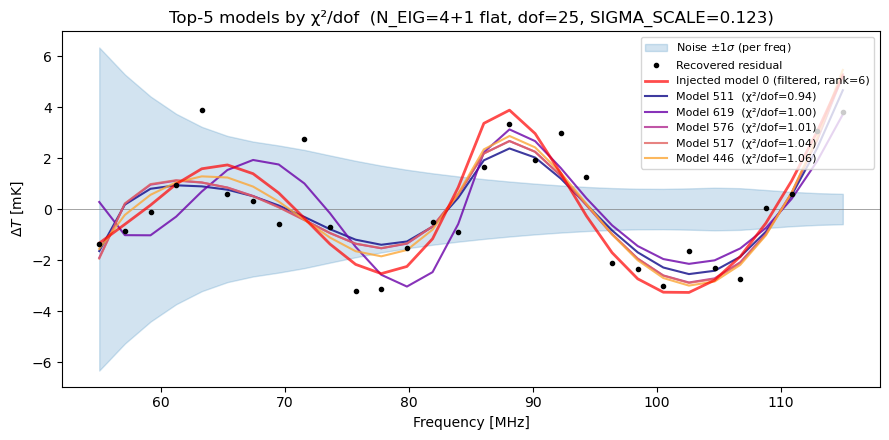

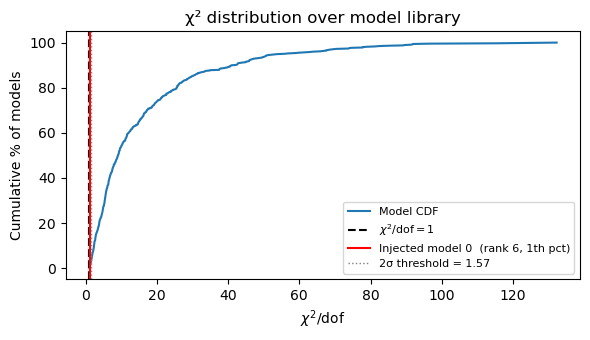

In [8]:
dof = N_FREQ - N_MODES_TOTAL

# Evaluate all models at the observation frequencies  (n_models, N_FREQ)
T_all      = models_21cm(FREQS_MHZ * 1e6)        # (n_models, N_FREQ)
T_all_filt = eigenmode_filter(T_all, modes)       # (n_models, N_FREQ)

# chi²/dof — per-frequency sigma weighting.
# SIGMA_MONO varies ~10× across the band, so the mean would under-weight
# the high-sensitivity (high-frequency) channels.
chi2_nu = np.sum(((resid_est - T_all_filt) / SIGMA_MONO[np.newaxis, :]) ** 2,
                  axis=1) / dof

# Signal recovery metrics
chi2_model0  = float(chi2_nu[INJ_MODEL_IDX])
rank_model0  = int(np.sum(chi2_nu <= chi2_model0))   # 1-based rank
pct_rank     = rank_model0 / len(chi2_nu) * 100.0
chi2_thresh  = 1.0 + 2.0 * np.sqrt(2.0 / dof)       # 2σ above expected chi²/dof=1

print(f'Model library: {len(models_21cm)} models  (dof={dof})')
print(f'chi²/dof  min={chi2_nu.min():.3f} (model {np.argmin(chi2_nu)}),  '
      f'median={np.median(chi2_nu):.3f}')
print(f'Injected model {INJ_MODEL_IDX}: chi²/dof={chi2_model0:.3f}  '
      f'rank={rank_model0}/{len(chi2_nu)} ({pct_rank:.1f}th pct)')

# ── Plot: residual with per-frequency noise band ───────────────────────────────
N_SHOW  = 5
best_idx = np.argsort(chi2_nu)[:N_SHOW]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(FREQS_MHZ, -SIGMA_MONO * 1e3, SIGMA_MONO * 1e3,
                alpha=0.2, color='C0', zorder=0, label=r'Noise $\pm 1\sigma$ (per freq)')
ax.axhline(0, color='gray', lw=0.5, zorder=0)
ax.plot(FREQS_MHZ, resid_est * 1e3, 'k.', ms=6, zorder=5,
        label='Recovered residual')
ax.plot(FREQS_MHZ, T_21_filt * 1e3, 'r-', lw=2, alpha=0.7, zorder=4,
        label=f'Injected model {INJ_MODEL_IDX} (filtered, rank={rank_model0})')

cmap = plt.cm.plasma
for rank, idx in enumerate(best_idx):
    c = cmap(rank / N_SHOW)
    lbl = f'Model {idx}  (χ²/dof={chi2_nu[idx]:.2f})'
    if idx == INJ_MODEL_IDX:
        lbl += '  ← injected'
    ax.plot(FREQS_MHZ, T_all_filt[idx] * 1e3, '-', color=c, lw=1.5, alpha=0.8, label=lbl)

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel(r'$\Delta T$ [mK]')
ax.set_title(f'Top-{N_SHOW} models by χ²/dof  '
             f'(N_EIG={N_EIG_MODES}+1 flat, dof={dof}, SIGMA_SCALE={SIGMA_SCALE})')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

# ── chi²/dof CDF ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
sorted_chi2 = np.sort(chi2_nu)
ax.plot(sorted_chi2, np.arange(1, len(chi2_nu)+1) / len(chi2_nu) * 100,
        'C0-', lw=1.5, label='Model CDF')
ax.axvline(1.0,          color='k',   lw=1.5, ls='--', label=r'$\chi^2/\mathrm{dof}=1$')
ax.axvline(chi2_model0,  color='r',   lw=1.5, ls='-',
           label=f'Injected model {INJ_MODEL_IDX}  (rank {rank_model0}, {pct_rank:.0f}th pct)')
ax.axvline(chi2_thresh,  color='gray', lw=1,  ls=':',
           label=f'2σ threshold = {chi2_thresh:.2f}')
ax.set_xlabel(r'$\chi^2 / \mathrm{dof}$')
ax.set_ylabel('Cumulative % of models')
ax.set_title('χ² distribution over model library')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
np.std(resid_est)

np.float64(0.0021467301821280127)